In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib


In [2]:
x_train_pre = joblib.load('x_train_presplit_smote.pkl')
y_train_pre = joblib.load('y_train_presplit_smote.pkl')
x_test_pre  = joblib.load('x_test_presplit_smote.pkl')
y_test_pre  = joblib.load('y_test_presplit_smote.pkl')

In [3]:
xgb_model_pre = XGBClassifier(
    n_estimators=100,
    random_state=20,
    eval_metric='logloss'
)
xgb_model_pre.fit(x_train_pre, y_train_pre)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [4]:
xgb_pred_pre = xgb_model_pre.predict(x_test_pre)
xgb_prob_pre = xgb_model_pre.predict_proba(x_test_pre)[:, 1]
print(xgb_prob_pre)

[9.86086249e-01 4.25068647e-01 9.00236309e-01 4.63774592e-01
 9.96146679e-01 3.59193841e-03 4.76854682e-01 9.95358884e-01
 9.73972261e-01 9.29691792e-01 1.40087560e-01 8.97222698e-01
 9.63323355e-01 9.00681138e-01 6.07231557e-01 9.97435868e-01
 9.99261320e-01 9.51987684e-01 9.72366214e-01 6.03339195e-01
 1.56778730e-02 7.74350669e-03 1.47948484e-03 8.27796641e-04
 2.81099789e-02 2.61450838e-02 4.78882134e-01 9.86999333e-01
 9.70606029e-01 9.58577871e-01 1.03675844e-02 3.69524513e-03
 1.42409594e-03 6.42183945e-02 9.80567992e-01 9.98460650e-01
 1.10419907e-01 7.12133422e-02 4.29224335e-02 5.44262886e-01
 9.65283345e-03 1.18282765e-01 2.25566025e-03 9.74701762e-01
 5.00606239e-01 9.62637305e-01 9.44169164e-01 2.86701918e-01
 3.74011755e-01 4.64875177e-02 1.09465897e-01 9.88254547e-01
 9.96537089e-01 9.96595562e-01 9.94628370e-01 1.84353843e-01
 4.23544198e-01 6.74467981e-01 5.69849834e-02 1.20396920e-01
 2.42091361e-02 9.94633079e-01 1.97047498e-02 5.49895242e-02
 8.90684500e-02 6.279974

In [5]:
xgb_accuracy_pre = accuracy_score(y_test_pre, xgb_pred_pre)
print("XGBoost Accuracy (Pre-split SMOTE):", round(xgb_accuracy_pre, 4))

XGBoost Accuracy (Pre-split SMOTE): 0.9102


In [6]:
print(classification_report(y_test_pre, xgb_pred_pre))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       339
           1       0.90      0.92      0.91       340

    accuracy                           0.91       679
   macro avg       0.91      0.91      0.91       679
weighted avg       0.91      0.91      0.91       679



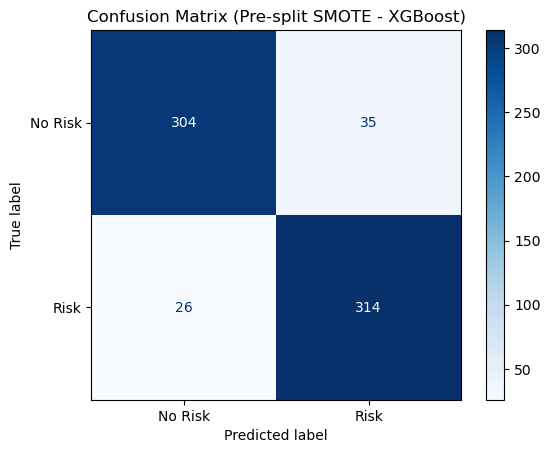

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test_pre, xgb_pred_pre,
    display_labels=['No Risk', 'Risk'],
    cmap='Blues'
)
plt.title("Confusion Matrix (Pre-split SMOTE - XGBoost)")
plt.show()

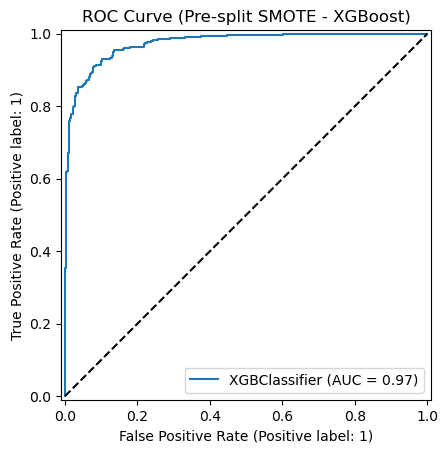

In [8]:
RocCurveDisplay.from_estimator(xgb_model_pre, x_test_pre, y_test_pre)
plt.title('ROC Curve (Pre-split SMOTE - XGBoost)')
plt.plot([0, 1], [0, 1], 'k--')
plt.show()

In [9]:
print('ROC-AUC Score:', roc_auc_score(y_test_pre, xgb_prob_pre).round(4))

ROC-AUC Score: 0.974


In [10]:
feature_names_pre = joblib.load('feature_names_presplit_smote.pkl')  # saved earlier
n_importances = len(xgb_model_pre.feature_importances_)

In [11]:
print("x_train_pre shape:", x_train_pre.shape)

x_train_pre shape: (2713, 28)


In [12]:
if len(feature_names_pre) == n_importances:
    labels = feature_names_pre
else:
    labels = [f"feature_{i}" for i in range(n_importances)]

feature_importance_pre = pd.DataFrame({
    "Feature": labels,
    "Importance": xgb_model_pre.feature_importances_
})

feature_importance_pre = feature_importance_pre.sort_values(by="Importance", ascending=False)
print(feature_importance_pre.to_string(index=False))

 Feature  Importance
      24    0.085760
      25    0.078067
      19    0.064506
      21    0.064280
      20    0.052939
      23    0.052715
      27    0.047187
      22    0.045022
      12    0.043749
      17    0.041060
       9    0.037251
      26    0.035444
      10    0.033524
      13    0.031560
       4    0.031514
      18    0.024814
       8    0.024754
       0    0.023993
       6    0.023340
      15    0.023272
      11    0.022567
       1    0.022546
      14    0.021109
       7    0.019594
      16    0.019463
       3    0.018294
       2    0.011675
       5    0.000000


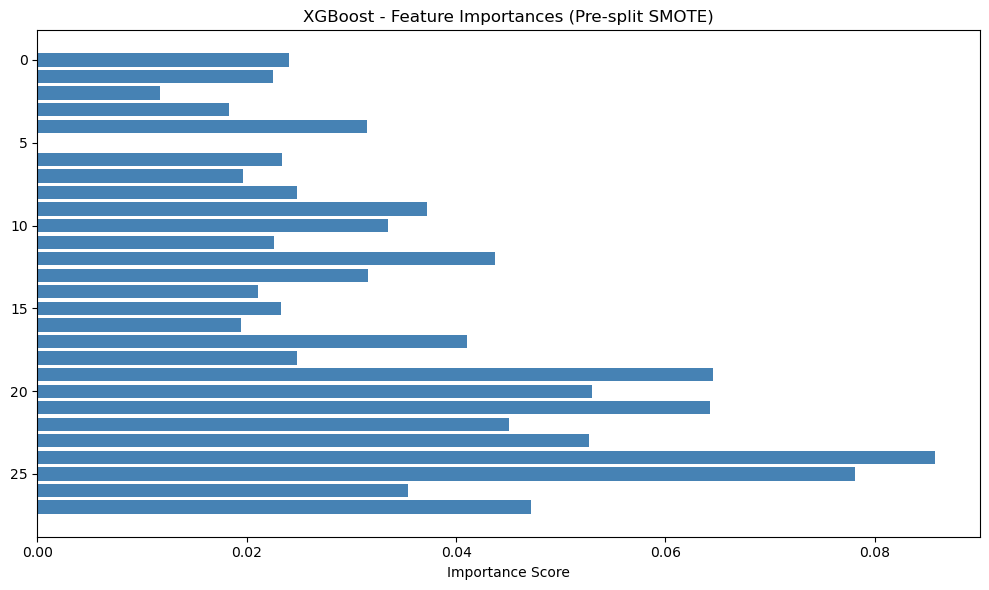

In [13]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_pre["Feature"], feature_importance_pre["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("XGBoost - Feature Importances (Pre-split SMOTE)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
train_pred_pre = xgb_model_pre.predict(x_train_pre)
train_accuracy_pre = accuracy_score(y_train_pre, train_pred_pre)
print("Train Accuracy:", round(train_accuracy_pre, 4))
print("Test Accuracy :", round(xgb_accuracy_pre, 4))

Train Accuracy: 1.0
Test Accuracy : 0.9102


In [15]:
precision_pre = precision_score(y_test_pre, xgb_pred_pre)
recall_pre    = recall_score(y_test_pre, xgb_pred_pre)
f1_pre        = f1_score(y_test_pre, xgb_pred_pre)

print("Precision:", round(precision_pre, 4))
print("Recall   :", round(recall_pre, 4))
print("F1 Score :", round(f1_pre, 4))

Precision: 0.8997
Recall   : 0.9235
F1 Score : 0.9115


In [16]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search_pre = GridSearchCV(
    XGBClassifier(random_state=20, eval_metric='logloss'),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search_pre.fit(x_train_pre, y_train_pre)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [17]:
print("Best Params:", grid_search_pre.best_params_)
best_model_pre = grid_search_pre.best_estimator_

Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}


In [18]:
best_pred_pre = best_model_pre.predict(x_test_pre)
best_prob_pre = best_model_pre.predict_proba(x_test_pre)[:, 1]
print("Best Model Accuracy:", round(accuracy_score(y_test_pre, best_pred_pre), 4))
print("Best Model ROC-AUC :", roc_auc_score(y_test_pre, best_prob_pre).round(4))


Best Model Accuracy: 0.919
Best Model ROC-AUC : 0.977


In [19]:
cv_scores_pre = cross_val_score(xgb_model_pre, x_train_pre, y_train_pre, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores_pre.round(4))
print("Mean:", cv_scores_pre.mean().round(4), "| Std dev:", cv_scores_pre.std().round(4))

CV ROC-AUC Scores: [0.9626 0.9585 0.9538 0.9763 0.9654]
Mean: 0.9633 | Std dev: 0.0076


In [20]:
joblib.dump(xgb_model_pre, 'xgboost_model_presplit_smote.pkl')
print("Model saved.")


Model saved.
